
# Logistic Regression

## 1. Import Libraries

In [1]:

import pandas as pd
import numpy as np

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt


## 2. Create Dataset

In [2]:

data = {
    'StudyHours': [1, 2, 3, 4, 5, 6],
    'Pass': [0, 0, 0, 1, 1, 1]
}

df = pd.DataFrame(data)

df


,StudyHours,Pass
0,1,0
1,2,0
2,3,0
3,4,1
4,5,1
5,6,1


## 3. Features and Target

In [3]:

X = df[['StudyHours']]
y = df['Pass']

print("Features")
display(X)

print("\nTarget")
display(y)


Features


,StudyHours
0,1
1,2
2,3
3,4
4,5
5,6



Target


,Pass
0,0
1,0
2,0
3,1
4,1
5,1


## 4. Train-Test Split

In [4]:

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train Shape:", X_train.shape)
print("X_test Shape :", X_test.shape)


X_train Shape: (4, 1)
X_test Shape : (2, 1)



## 5. Feature Scaling

We use StandardScaler to scale the feature values.


In [5]:

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("Scaled Training Data")
print(X_train_scaled)


Scaled Training Data
[[ 1.34164079]
 [-1.34164079]
 [ 0.4472136 ]
 [-0.4472136 ]]


## 6. Create Logistic Regression Model

In [6]:

model = LogisticRegression(random_state=42)

model


LogisticRegression(random_state=42)

## 7. Train the Model

In [7]:

model.fit(X_train_scaled, y_train)

print("Logistic Regression Model Trained Successfully")


Logistic Regression Model Trained Successfully


## 8. Predictions

In [8]:

predictions = model.predict(X_test_scaled)

print("Predicted Classes")
print(predictions)


Predicted Classes
[0 0]


## 9. Prediction Probabilities

In [9]:

probabilities = model.predict_proba(X_test_scaled)

print(probabilities)


[[0.77589677 0.22410323]
 [0.62927629 0.37072371]]


In [10]:
# model.classes_ returns the list of class labels learned by the model during training.
# The order of these classes determines the column order in: model.predict_proba

# Meaning: If output: [0 1]
# First probability column → class 0
# Second probability column → class 1

print(model.classes_)

[0 1]



## 10. Predict New Student

Predict result for:
Study Hours = 4.5


In [11]:

new_data = [[4.5]]

new_scaled = scaler.transform(new_data)

prediction = model.predict(new_scaled)

probability = model.predict_proba(new_scaled)

print("Predicted Class:", prediction[0])

print("\nPrediction Probability")
print(probability)


Predicted Class: 1

Prediction Probability
[[0.22220112 0.77779888]]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


## 11. Accuracy Score

In [12]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

accuracy = accuracy_score(y_test, predictions)

print("Accuracy:", accuracy)


Accuracy: 1.0


## 12. Confusion Matrix

In [13]:

cm = confusion_matrix(y_test, predictions)

print(cm)


[[2]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


## 13. Classification Report

In [14]:

report = classification_report(y_test, predictions)

print(report)


              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2

    accuracy                           1.00         2
   macro avg       1.00      1.00      1.00         2
weighted avg       1.00      1.00      1.00         2



## 14. Visualize Dataset

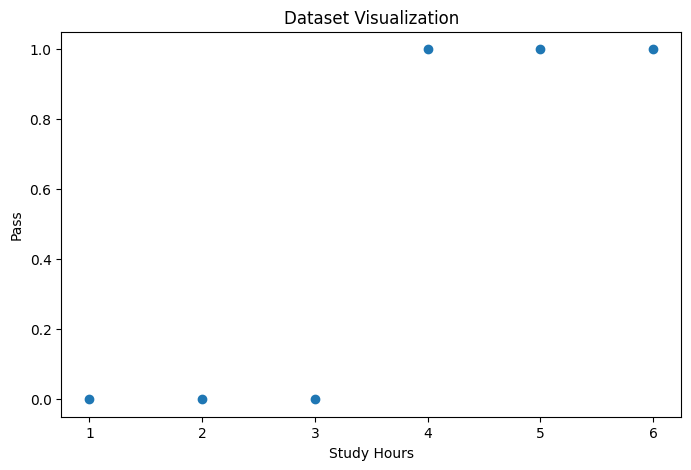

In [15]:

plt.figure(figsize=(8,5))

plt.scatter(X, y)

plt.xlabel("Study Hours")
plt.ylabel("Pass")

plt.title("Dataset Visualization")

plt.show()


## 15. Sigmoid Function Visualization

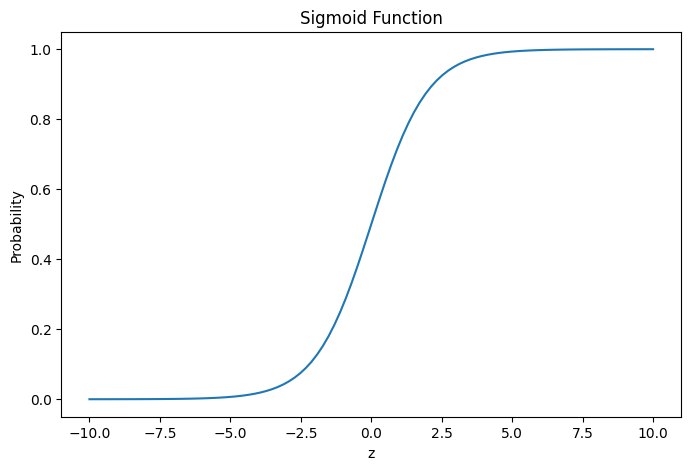

In [16]:

x = np.linspace(-10, 10, 100)

y_sigmoid = 1 / (1 + np.exp(-x))

plt.figure(figsize=(8,5))

plt.plot(x, y_sigmoid)

plt.xlabel("z")
plt.ylabel("Probability")

plt.title("Sigmoid Function")

plt.show()


## 16. Decision Boundary

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


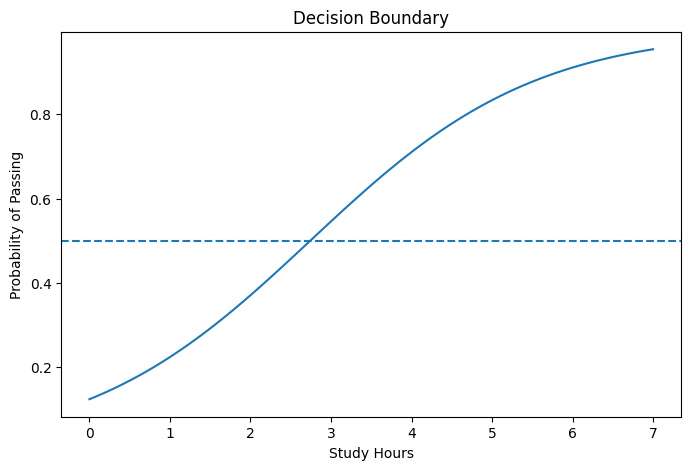

In [17]:

study_hours = np.linspace(0, 7, 100).reshape(-1,1)

study_hours_scaled = scaler.transform(study_hours)

probabilities = model.predict_proba(study_hours_scaled)[:,1]

plt.figure(figsize=(8,5))

plt.plot(study_hours, probabilities)

plt.axhline(y=0.5, linestyle='--')

plt.xlabel("Study Hours")
plt.ylabel("Probability of Passing")

plt.title("Decision Boundary")

plt.show()


## 17. Model Coefficients

In [18]:

print("Coefficient:", model.coef_)

print("Intercept:", model.intercept_)


Coefficient: [[0.79693391]]
Intercept: [1.25288506]



# 18. Final Summary

Logistic Regression:

- Predicts probabilities
- Uses sigmoid function
- Performs binary classification
- Uses decision boundary
- Produces interpretable results


### For more reference: https://youtu.be/jN8-xBel2xk